# Шейплеты и временные ряды  

В этом блокноте наша цель — познакомить с использованием шейплетов для временных рядов. И первый раз мы поработаем с библиотекой *aeon*, документацию по которой можно прочесть по ссылке [документации](https://www.aeon-toolkit.org/en/stable/).

 Мы приводем примеры использования преобразований, классификации и регрессионных оценок на основе шейплетов с двумя наборами данных примеров KDD. Мы также посмотрим, как использовать инструменты визуализации, связанные с этими оценщиками.

In [1]:
!pip install aeon
!mkdir -p data
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TEST.ts -P data/

'pip' is not recognized as an internal or external command,
operable program or batch file.


A subdirectory or file -p already exists.
Error occurred while processing: -p.
A subdirectory or file data already exists.
Error occurred while processing: data.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# There are some deprecation warnings present in the notebook, we will ignore them.
# Remove this cell if you are interested in finding out what is changing soon, for
# aeon there will be big changes in out v1.0.0 release!
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

Давайте сначала сделаем импорт и загрузим наборы данных (это может занять некоторое время, если вы импортируете их впервые!):

In [3]:
import numpy as np
from aeon.datasets import load_classification
from aeon.transformations.collection.shapelet_based import (
    RandomShapeletTransform,
)
from aeon.classification.shapelet_based import (
    ShapeletTransformClassifier,
    RDSTClassifier,
)
from aeon.testing.data_generation import make_example_3d_numpy

Поскольку большинство импортированных нами оценщиков используют numba, первый вызов методов fit/predict потребует некоторого времени для компиляции функций и их кэширования. Чтобы ускорить компиляцию, при первом вызове их в вашей системе вы можете вызвать их для фиктивного набора данных с определенным набором параметров (это может занять ~ 1-2 минуты):

In [4]:
X = make_example_3d_numpy(return_y=False, n_cases=5)
y = np.array([0, 1, 0, 1, 0])

for Classifier in [ShapeletTransformClassifier, RDSTClassifier]:
    print(f"Compiling {Classifier.__name__}")
    clf = Classifier()
    clf.fit(X, y)
    preds = clf.predict(X)
    print(f"✅ Predictions: {preds}")

Compiling ShapeletTransformClassifier


✅ Predictions: [0 1 0 1 0]
Compiling RDSTClassifier
✅ Predictions: [0 1 0 1 0]


C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:267: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  return self._transform(X, y)
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)


Вы можете выполнить указанную выше ячейку еще раз и увидеть, что теперь она выполняется мгновенно! (Обратите внимание, что у RDST есть параметр distance, который, если его изменить, вызовет новый этап компиляции). 

Теперь мы загружаем пример набора данных:

In [5]:
from pathlib import Path
from aeon.datasets import load_from_ts_file

train_candidates = [Path('data/KDD_UTSC_TRAIN.ts'), Path('dataset/KDD_UTSC_TRAIN.ts')]
test_candidates = [Path('data/KDD_UTSC_TEST.ts'), Path('dataset/KDD_UTSC_TEST.ts')]
train_path = next((p for p in train_candidates if p.exists()), None)
test_path = next((p for p in test_candidates if p.exists()), None)
if train_path is None or test_path is None:
    raise FileNotFoundError('KDD_UTSC train/test .ts files not found in data/ or dataset/')

X_train, y_train = load_from_ts_file(str(train_path))
X_test, y_test = load_from_ts_file(str(test_path))
print('train path:', train_path)
print('test path:', test_path)
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('classes:', np.unique(y_train))


train path: dataset\KDD_UTSC_TRAIN.ts
test path: dataset\KDD_UTSC_TEST.ts
X_train: (40, 1, 100) X_test: (40, 1, 100)
classes: ['rest' 'task']


# Машинное обучение временных рядов на основе шейплетов 

Структура классификации (классификации) на основе шейплетов представлена на изображении ниже:

<img src="data\aeon\shp_general.png?raw=1" alt="drawing" width="700"/>

Сначала шейплеты $k$ генерируются с использованием обучающих данных (с параметром $k$), затем, выполняя преобразование шейплетов с сгенерированными шейплетами и некоторым набором данных временных рядов с $n$ выборками, мы получаем матрицу признаков размера $(n,k)$, эта матрица затем используется табличным классификатором, например, каждая выборка описывается $k$ признаками, полученными с помощью шейплетов. 

Этот шаг создания шейплета и извлечения признаков можно выполнить с помощью оценщиков в `aeon.transformation.collection.shapelet_based`, например, используя `RandomShapeletTransform`:

In [6]:
rst = RandomShapeletTransform().fit(
    X_train, y_train
)
X_T = rst.transform(X_test)
print(X_test.shape)
print(X_T.shape)

(40, 1, 100)
(40, 79)


## Какие функции извлекаются с помощью фигурок? 

Признаки, извлеченные с помощью шейплетов, извлекаются из вектора расстояния, который хранит расстояние между шейплотом $S$ (размера $l$) и каждой подпоследовательностью того же размера во временном ряду $X$. Например, RandomShapeletTransform извлекает минимум из этого вектора расстояния. Более формально, используя евклидово расстояние:

$\displaystyle{\min\limits_{i\ :1, \ldots, m-l+1} \sqrt{\sum_{j=0}^{l-1}(\mathbf{s}_j - \mathbf{x}_{i+j})^2}}$

Это отражает основную идею о том, что расстояние шейплета до временного ряда определяется как расстояние между шейплетом и наиболее подходящей подпоследовательностью того же размера в $X$. Мы можем проиллюстрировать эту формулу следующим изображением, где мы извлекаем минимум из значений $v$ :

<img src="data\aeon\ex_shp_simple.png?raw=1" alt="drawing" width="500"/>

(Немного не по теме, но такой вектор расстояния можно эффективно вычислить с помощью оценщика `QuerySearch` в модуле `similarity_search`, используя шейплет в качестве запроса.)

Обратите внимание, что в других средствах оценки, таких как RandomDilatedShapeletTransform, размер матрицы признаков на самом деле равен $(n, 3k)$, поскольку из каждой фигуры извлекаются 3 признака: 

- $\text{argmin} V$ : местоположение наилучшего соответствия, где местоположение – это положение передней части шейплета. 
- $\sum_i I(v_i < \lambda)$ : признак появления шейплета, который подсчитывает, сколько раз $S$ был $\lambda$-близок к $X$ (с $I$ — тождественной функцией). 

Добавление большего количества функций позволяет шейплетам быть дискриминационными по большему количеству критериев (количество совпадений $\lambda-close$, местоположение наилучшего совпадения), чем только расстояние наилучшего совпадения.

Еще одна интересная идея заключается в том, как шейплоты генерируются из входных временных рядов. А пока просто знайте, что либо производится исчерпывающий поиск с учетом всех возможных кандидатов, либо этот поиск аппроксимируется с использованием эвристик или случайных подходов. Также возможно изучить шейплоты, и это подход, используемый в «LearningShapeletClassifier».

# Шейплеты для классификации (или регрессии)

Теперь, когда мы понимаем основы, мы можем начать использовать классификаторы на основе шейплетов, такие как «ShapeletTransformClassifier» (или «RDSTRegressor» для регрессии). Метод fit будет извлекать фигурки, выполнять преобразование обучающих данных и по умолчанию обучать классификатор RotationForestClassifier на преобразованных данных. Вы можете выбрать, какой классификатор вы хотите использовать, либо с помощью параметра «оценщик», либо самостоятельно построив конвейер на основе преобразования. Например, с помощью средства оценки RidgeClassifierCV:

In [7]:
from sklearn.linear_model import RidgeClassifierCV

stc = ShapeletTransformClassifier(estimator=RidgeClassifierCV(), max_shapelet_length=33).fit(
    X_train, y_train
)
print(f"Accuracy : {stc.score(X_test, y_test)}")

Accuracy : 0.6


Мы можем визуализировать классификаторы на основе шейплетов, используя класс ShapeletClassifierVisualizer, который предоставляет методы для построения сгенерированных шейплетов, векторов расстояний, создаваемых ими признаков и того, как они соответствуют данным. Когда это возможно (в зависимости от типа классификатора), мы также можем построить лучшие фигурки на основе критериев важности признаков из подобранного классификатора. Например, с только что использованным `ShapeletTransformClassifier` (диаграммы рассеяния могут запутаться при использовании длинных фигур!):

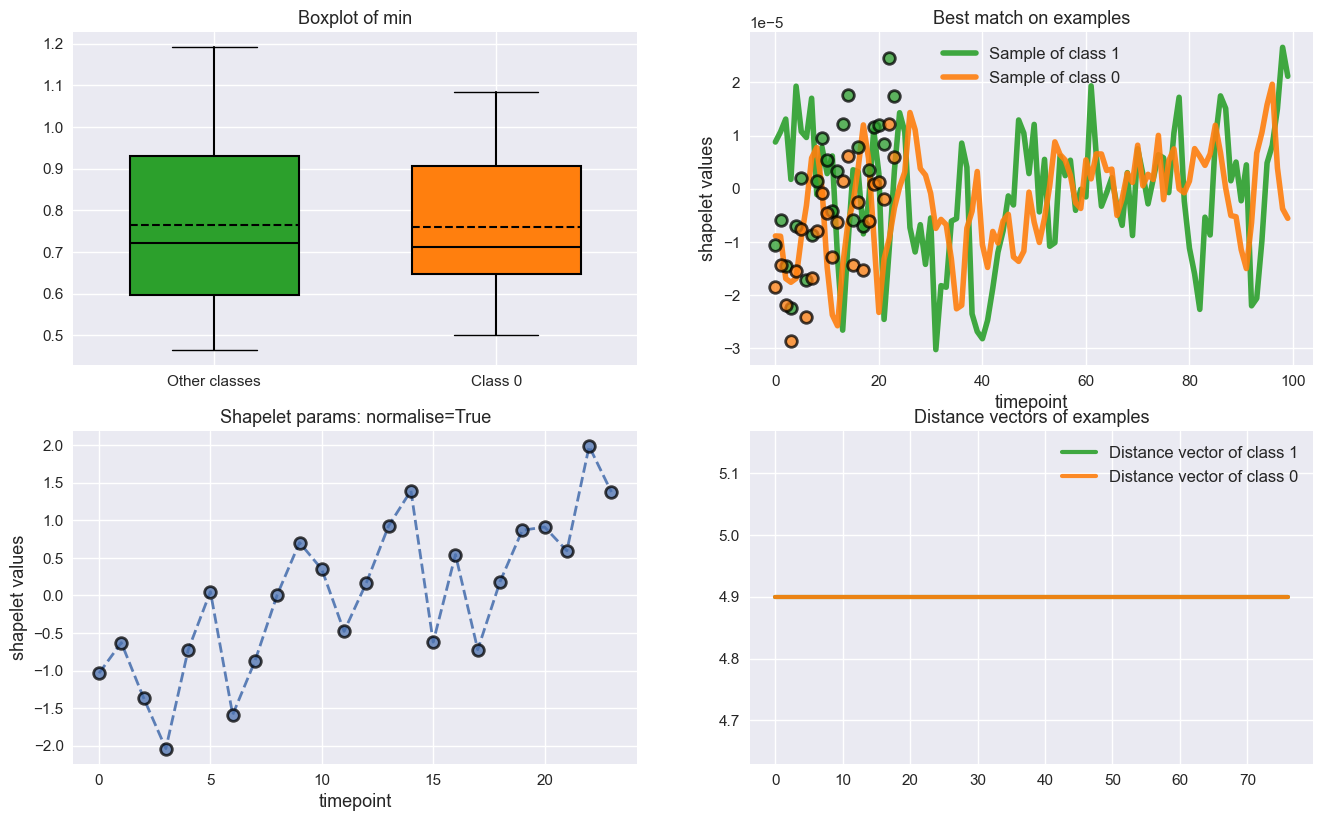

In [8]:
from aeon.visualisation import ShapeletClassifierVisualizer

stc_vis = ShapeletClassifierVisualizer(stc)
id_class = 0 # Show the best shapelet for class 0
fig = stc_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    id_class,
    figure_options={"figsize": (16,9.5), "nrows": 2, "ncols": 2}, # Some options to make a beatiful plot
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2}, # Some options to make a beatiful plot
    rc_Params_options={  # Some options to make a beatiful plot
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
},
)

Каждый из четырех графиков помогает интерпретировать алгоритмы на основе шейплетов. Здесь мы берем наиболее отличительную от всех форму класса 0 и исследуем ее как на локальные, так и на глобальные закономерности. 

- Boxplot of Min (вверху слева): этот график представляет новую перспективу, фокусируясь на глобальном качестве шейплета. Он показывает распределение минимальных расстояний между шейплотом и каждым временным рядом по разным классам. Как и ожидалось, шейплет соответствует классу 0 больше, чем другим классам. 

- Лучшее совпадение в примерах (вверху справа): этот график расширяет визуализацию наилучшего соответствия, показывая, как шейплет соответствует случайному временному ряду из каждого класса. Зеленые и оранжевые кривые представляют образцы классов 1 и 0 соответственно. Шейплет должен более точно соответствовать временному ряду органжа класса 0, что иллюстрирует его эффективность в различении двух классов в соответствии с локальным шаблоном. 

- Параметры шейплета (внизу слева): этот уже представленный график элегантно отображает динамику шейплета с течением времени. 

- Векторы расстояний примеров (внизу справа): этот график является расширением визуализации вектора расстояния, предлагая сравнение того, насколько хорошо шейплет соответствует двум временным рядам из графика «Наилучшее совпадение примеров» в каждой точке. Это позволяет получить глобальное представление о том, насколько хорошо шейплет соответствует временному ряду в любой момент.

Мы можем попробовать использовать RDSTClassifier, который использует понятие расширения для фигурок, а также извлекает еще 2 функции:

C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:267: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  return self._transform(X, y)
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\visualisation\estimator\_shapelets.py:731: UserWarning: Shapelet importance ranking may be unreliable when using linear classifiers with RDST. This is due to the interaction between argmin and shapelet occurrence features, which can distort the rankings. Consider evaluating the results carefully or using an alternative method.
  warnings.warn(


Accuracy : 0.925


C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)


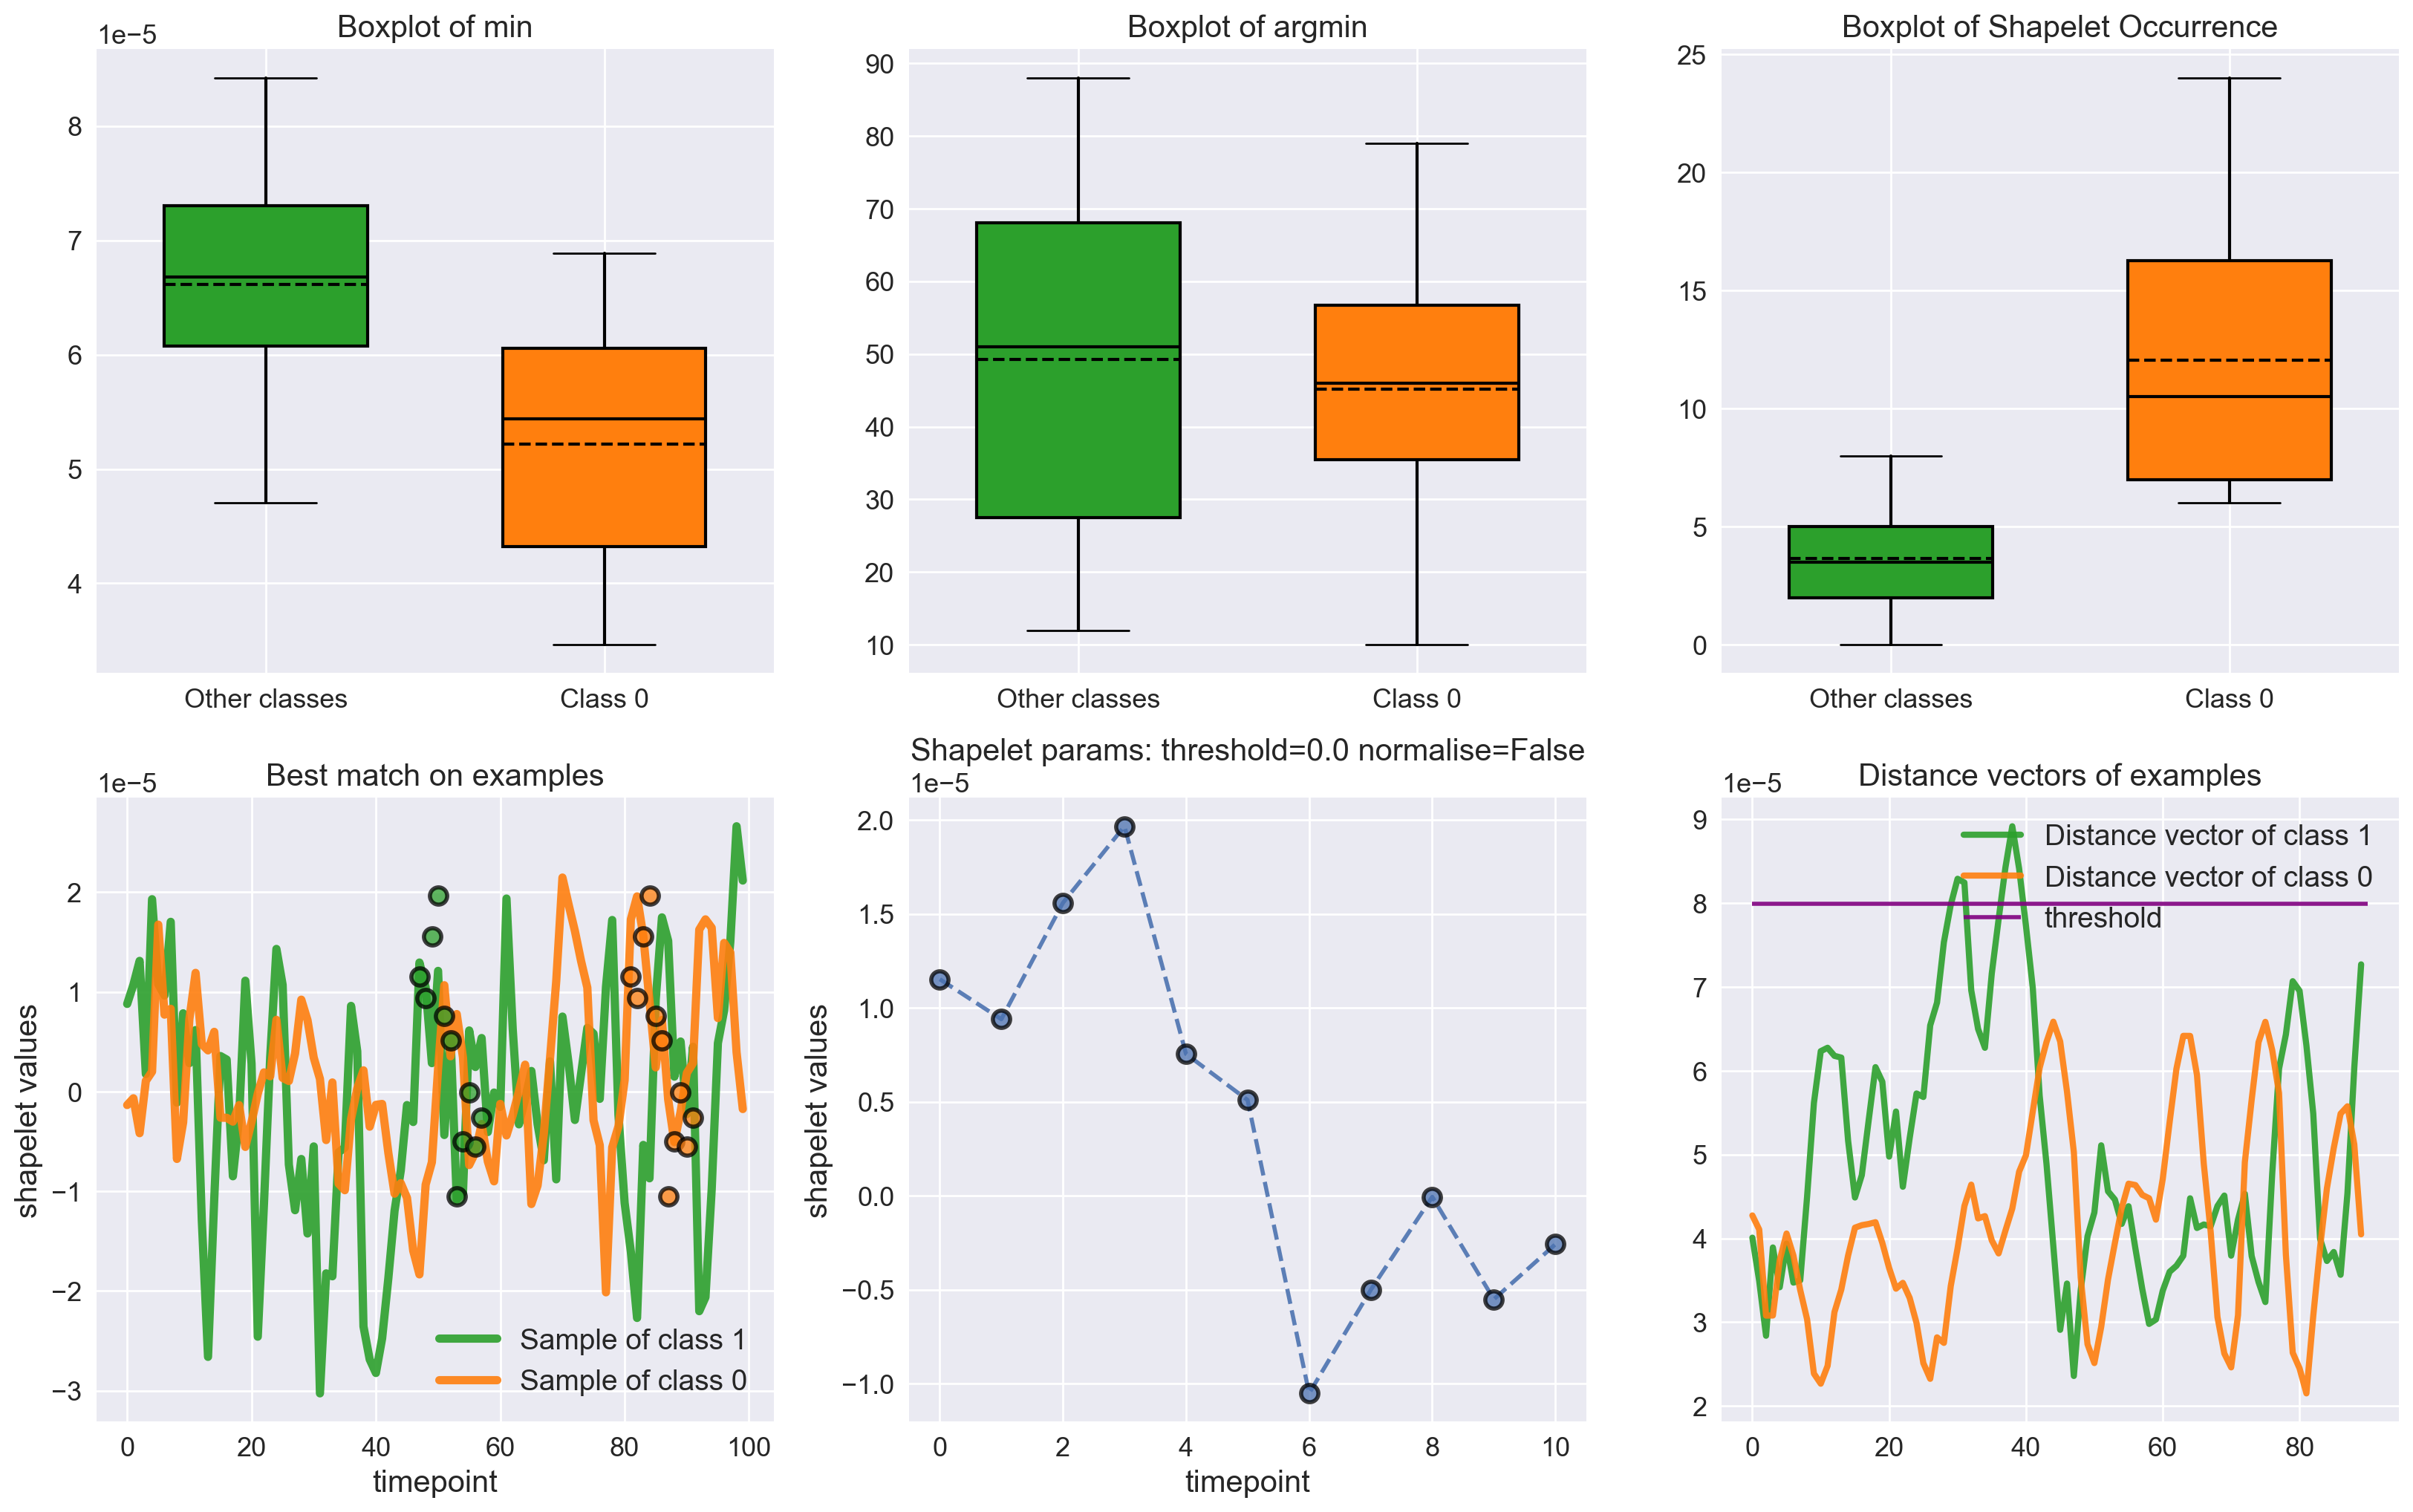

In [9]:
rdst = RDSTClassifier().fit(
    X_train, y_train
)
print(f"Accuracy : {rdst.score(X_test, y_test)}")

rdst_vis = ShapeletClassifierVisualizer(rdst)
id_class = 0 # Best shapelet for class 0
fig = rdst_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    id_class,
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
)

Доступно множество параметров для распараллеливания или настройки этих оценщиков, **которые поддерживают как многомерные временные ряды, так и временные ряды неравной длины**. Мы советуем вам взглянуть на документацию `aeon` для более глубокого погружения в шейплеты!.

## Результаты бенчмарка TSC

(<Figure size 600x240 with 1 Axes>, <Axes: >)

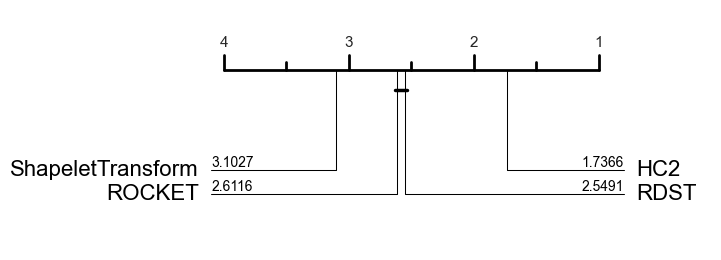

In [10]:
try:
    from aeon.benchmarking import get_estimator_results_as_array
except ImportError:
    from aeon.benchmarking.results_loaders import get_estimator_results_as_array

from aeon.datasets.tsc_datasets import univariate
from aeon.visualisation import plot_critical_difference

est = ['ROCKETClassifier', 'RDSTClassifier', 'ShapeletTransformClassifier', 'HC2']
names = [t.replace('Classifier', '') for t in est]
results, present_names = get_estimator_results_as_array(names, univariate, include_missing=False)
plot_critical_difference(results, names)


Чтобы сравнить производительность shapelet с другим методом SotA, мы сравниваем RDSTClassifier и ShapeletTransformClassifier с Rocket и HC2. Обратите внимание, что RDST и ROCKET считаются эквивалентными, что неудивительно. А вы сможете объяснить  почему?

## Упражнения  

1. Выбрать и скачать один из наборов данных с сайта [timeseriesclassification](https://www.timeseriesclassification.com/dataset.php). 

    Подробнее о датасетах, их форматах, и как их скачивать - [Ноутбук](https://github.com/aeon-toolkit/aeon/blob/main/examples/datasets/data_loading.ipynb)

2.  Записать название выбранного датасета в таблицу. Помните - совпадений быть не должно. Каждый работает с уникальным датасетом. Этот датасет вам понадобиться в лабе 14 (aeon) и лабе 16 (tslean)

3. Проанализировать датасет

4. Найти шейплеты для классов в датесете

5. Провести классификацию на основе шейплетов.

In [11]:
import numpy as np
from aeon.datasets import load_classification

X, y = load_classification('BeetleFly')

print(f"Общее количество примеров (временных рядов): {len(X)}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {np.unique(y)}")

unique, counts = np.unique(y, return_counts=True)
print("\nРаспределение по классам:")
for cls, cnt in zip(unique, counts):
    print(f"  Класс '{cls}': {cnt} примеров ({cnt/len(y)*100:.1f}%)")

print(f"\nФорма данных одного примера: {X[0].shape}")

Общее количество примеров (временных рядов): 40
Количество классов: 2
Названия классов: ['1' '2']

Распределение по классам:
  Класс '1': 20 примеров (50.0%)
  Класс '2': 20 примеров (50.0%)

Форма данных одного примера: (1, 512)


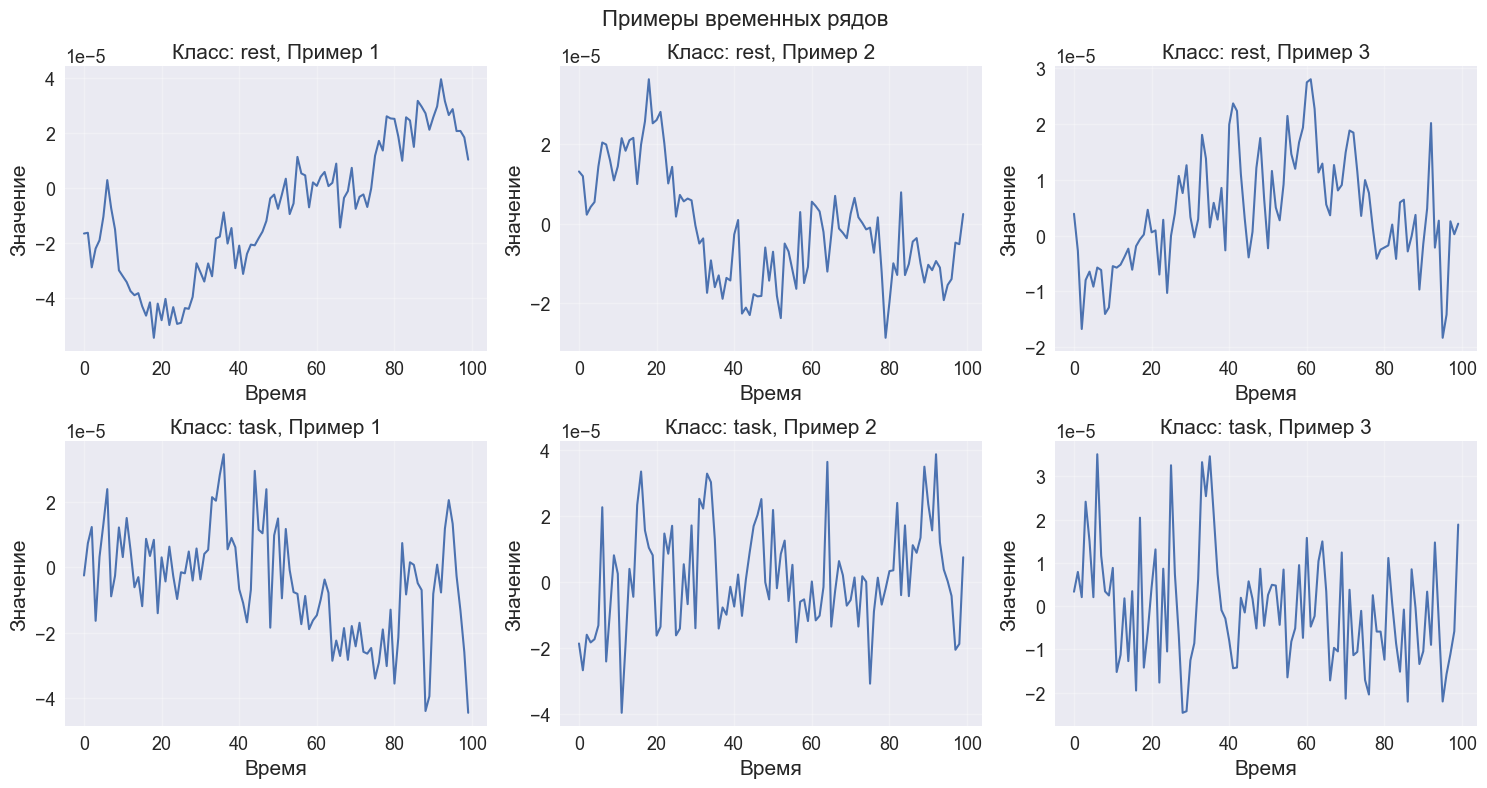

Основные статистики для каждого канала измерения:

Канал 0:
  Среднее: 0.0000
  Стандартное отклонение: 0.0000
  Минимум: -0.0001
  Максимум: 0.0001


In [12]:
import numpy as np
import matplotlib.pyplot as plt

X = X_train if 'X_train' in globals() else X
y = y_train if 'y_train' in globals() else y

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Примеры временных рядов', fontsize=16)

for i, class_label in enumerate(np.unique(y)):
    class_indices = np.where(y == class_label)[0][:3]
    
    for j, idx in enumerate(class_indices):
        ax = axes[i, j]

        for channel in range(X[idx].shape[0]):
            ax.plot(X[idx][channel], linewidth=1.5)
        ax.set_title(f'Класс: {class_label}, Пример {j+1}')
        ax.set_xlabel('Время')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Основные статистики для каждого канала измерения:")
for channel in range(X[0].shape[0]):
    channel_data = np.concatenate([x[channel] for x in X])
    print(f"\nКанал {channel}:")
    print(f"  Среднее: {np.mean(channel_data):.4f}")
    print(f"  Стандартное отклонение: {np.std(channel_data):.4f}")
    print(f"  Минимум: {np.min(channel_data):.4f}")
    print(f"  Максимум: {np.max(channel_data):.4f}")

In [13]:
from aeon.classification.shapelet_based import ShapeletTransformClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

stc = ShapeletTransformClassifier(
    n_shapelet_samples=1000,
    max_shapelets=50,
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

stc.fit(X_train, y_train)

y_pred = stc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность классификации на тестовой выборке: {accuracy:.3f}")


Точность классификации на тестовой выборке: 0.917


[<Figure size 1600x950 with 4 Axes>]

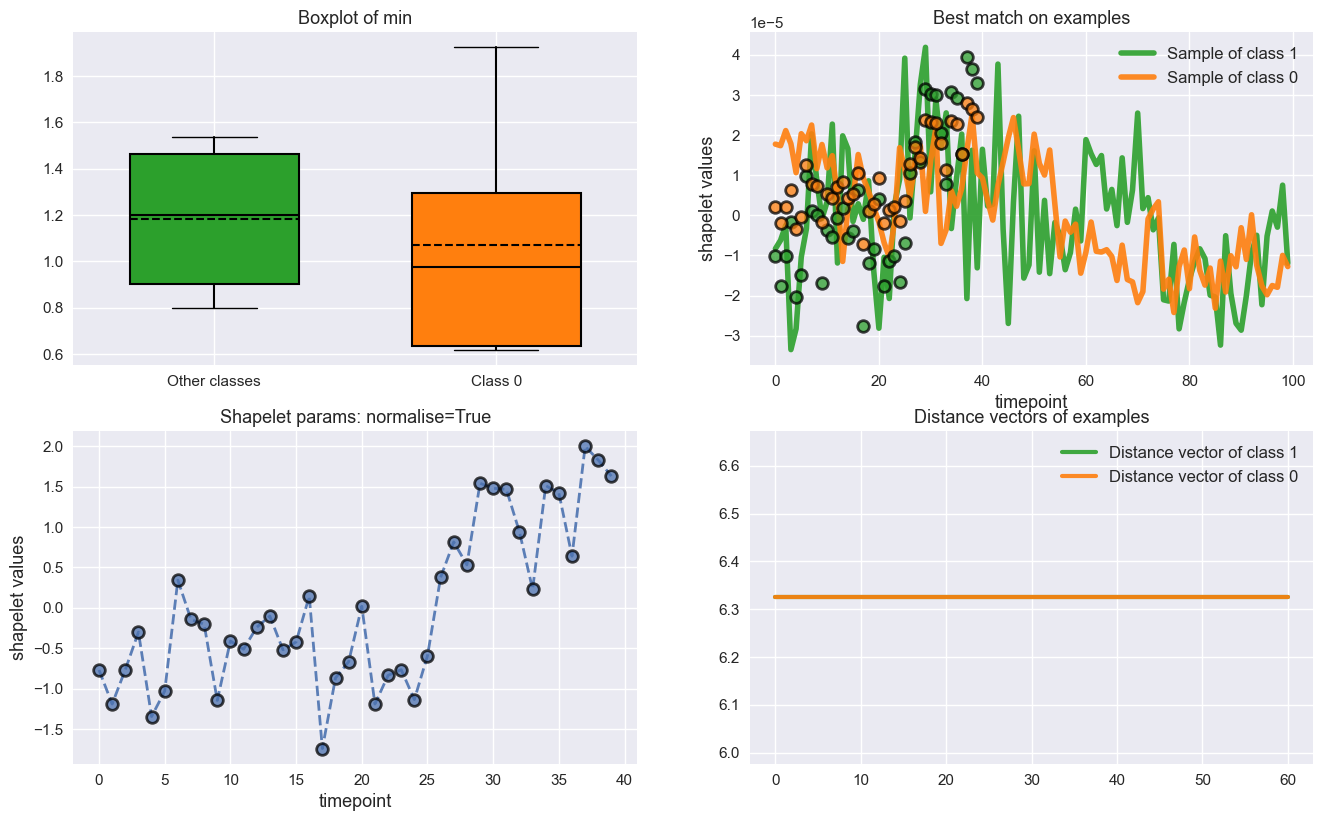

In [14]:
stc_vis = ShapeletClassifierVisualizer(stc)

stc_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    0,
    figure_options={"figsize": (16,9.5), "nrows": 2, "ncols": 2},
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
    rc_Params_options={
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
},
)

[<Figure size 1600x950 with 4 Axes>]

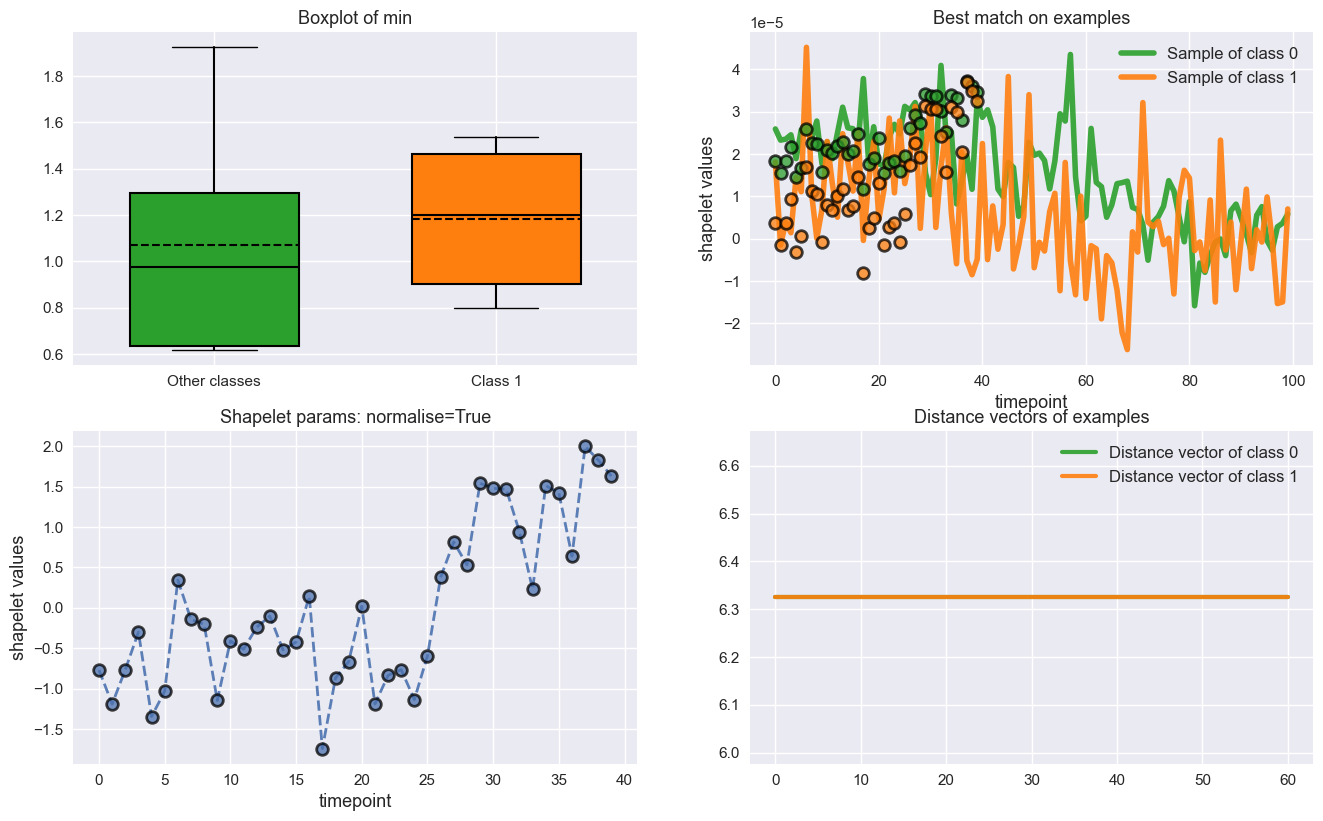

In [15]:
stc_vis = ShapeletClassifierVisualizer(stc)

stc_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    1,
    figure_options={"figsize": (16,9.5), "nrows": 2, "ncols": 2},
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
    rc_Params_options={
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
},
)

In [16]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

              precision    recall  f1-score   support

        rest       0.86      1.00      0.92         6
        task       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

Матрица ошибок:
[[6 0]
 [1 5]]


In [17]:
rdst = RDSTClassifier().fit(
    X_train, y_train
)

y_pred = rdst.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность классификации на тестовой выборке : {accuracy:.3f}")

Точность классификации на тестовой выборке : 1.000


C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:267: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  return self._transform(X, y)
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)


C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\visualisation\estimator\_shapelets.py:731: UserWarning: Shapelet importance ranking may be unreliable when using linear classifiers with RDST. This is due to the interaction between argmin and shapelet occurrence features, which can distort the rankings. Consider evaluating the results carefully or using an alternative method.
  warnings.warn(
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)


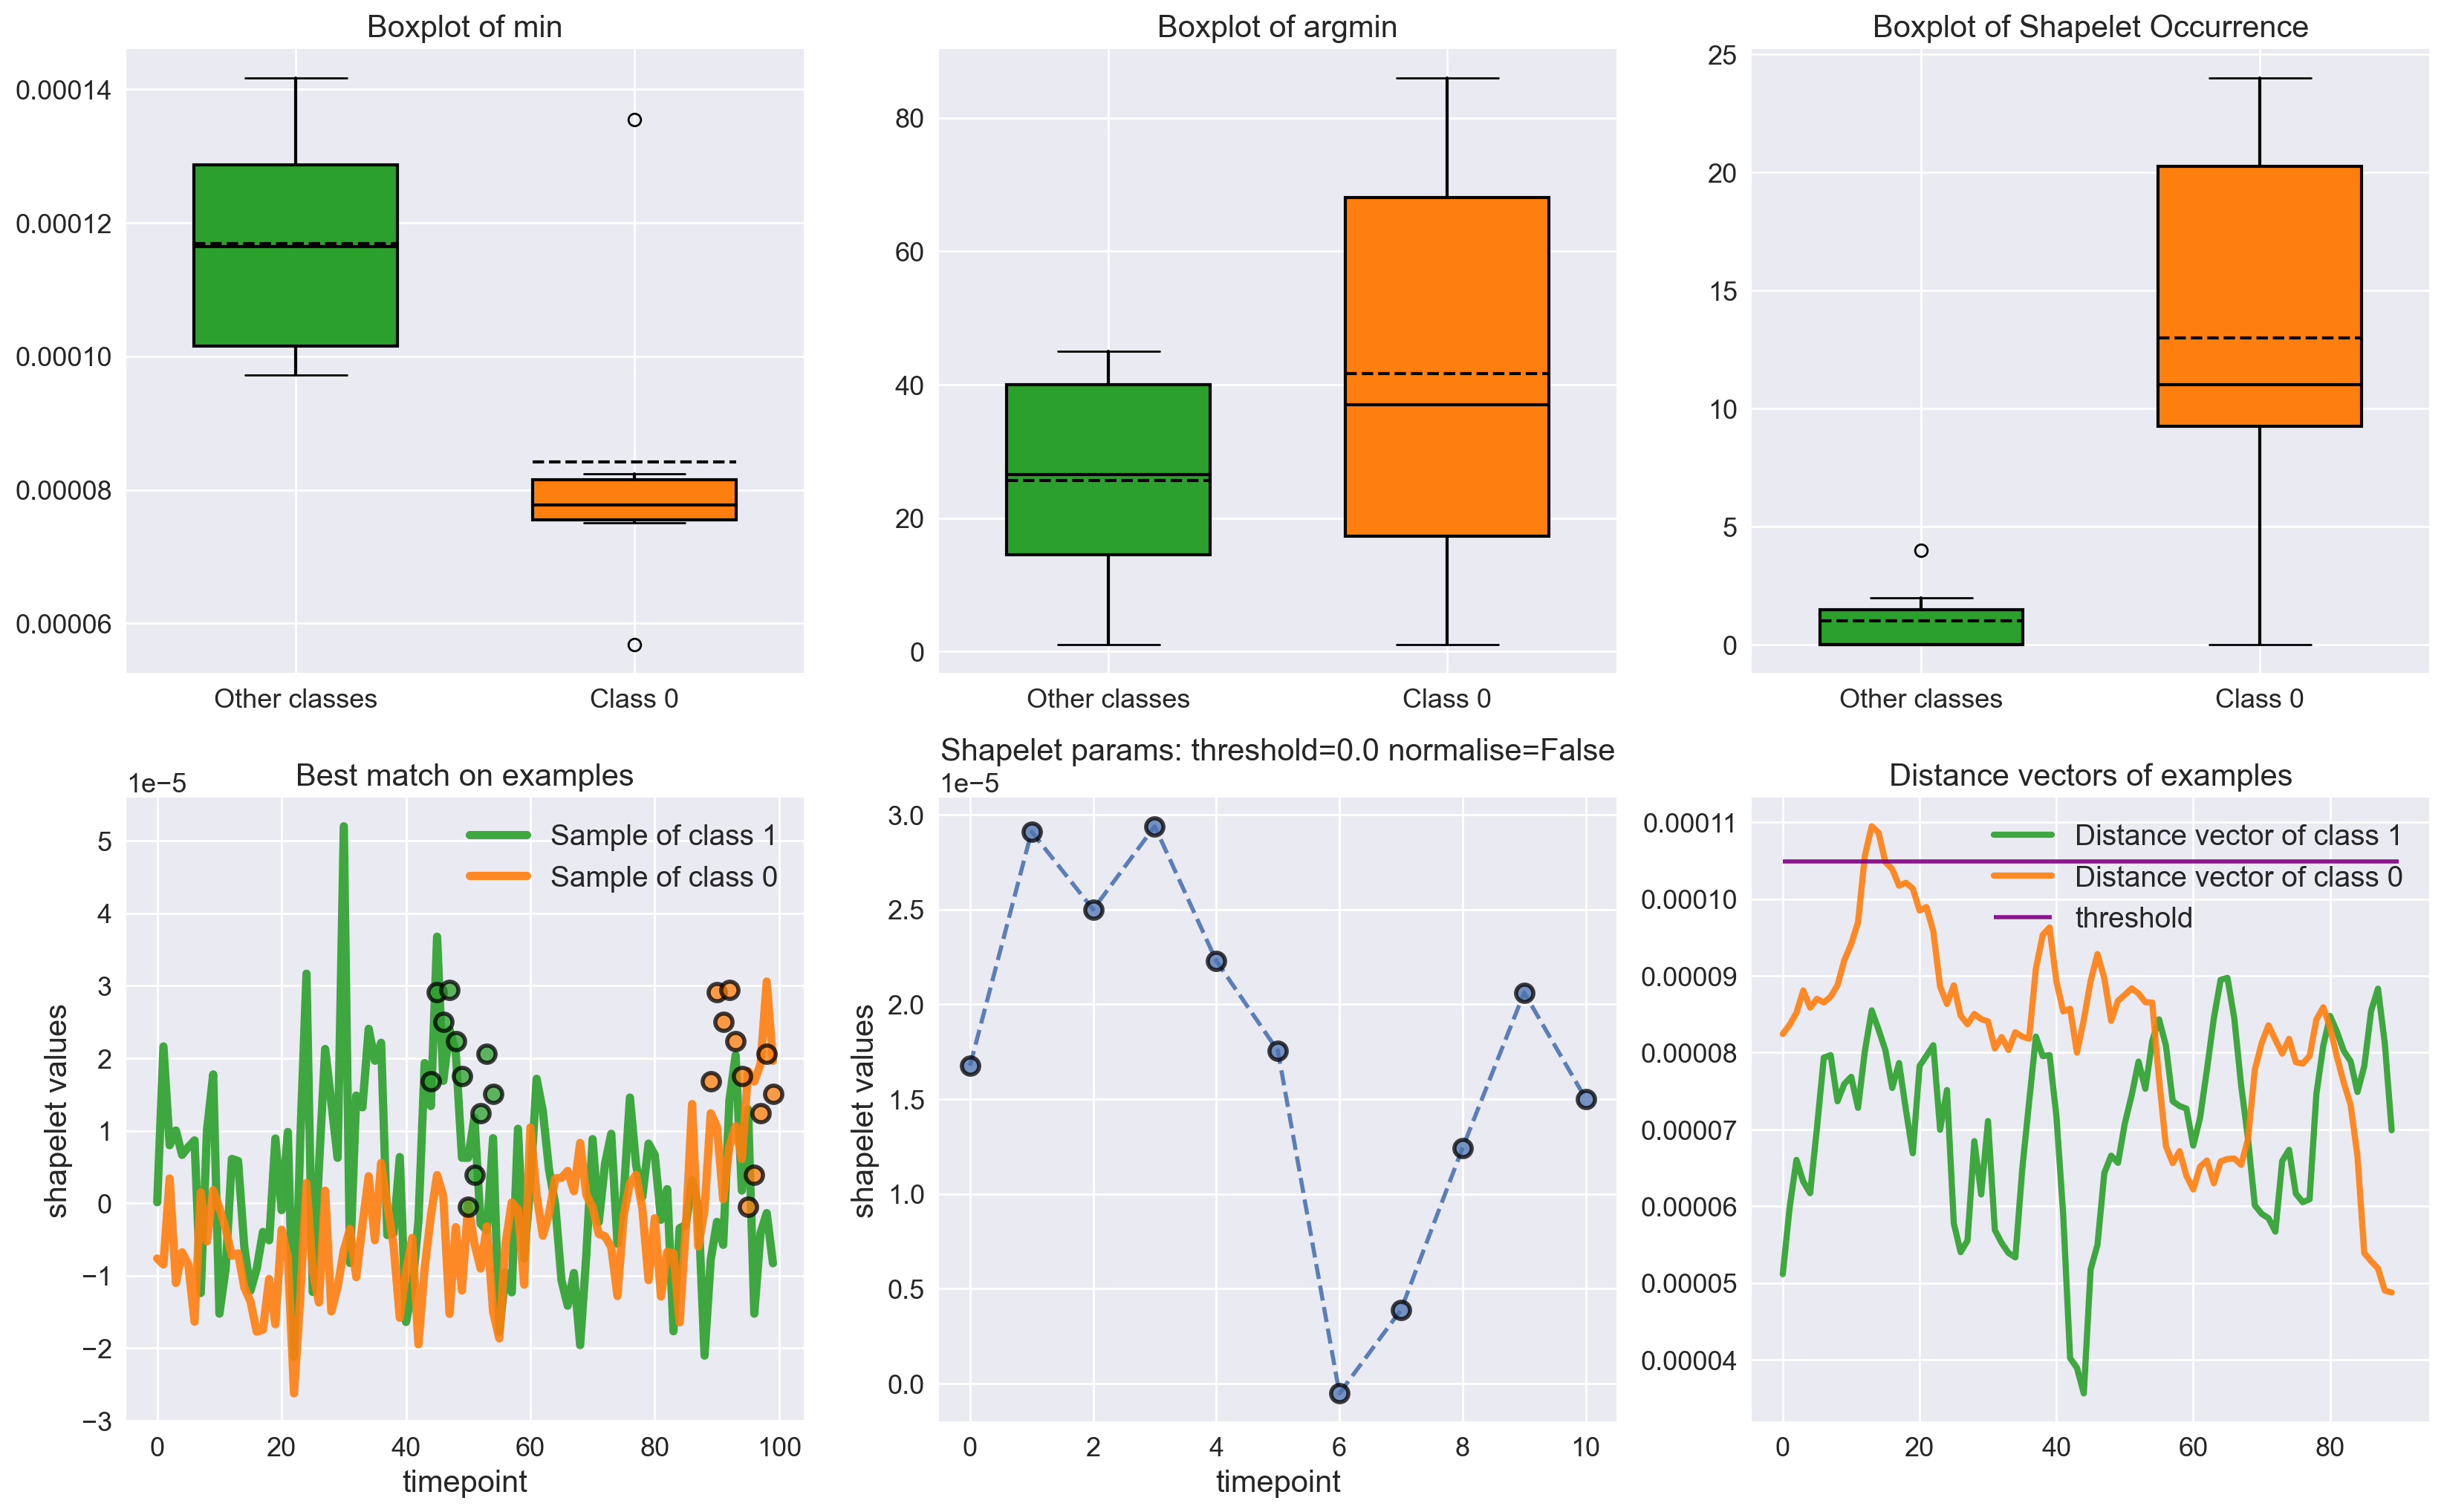

In [18]:
rdst_vis = ShapeletClassifierVisualizer(rdst)

fig = rdst_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    0,
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
)

C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\visualisation\estimator\_shapelets.py:731: UserWarning: Shapelet importance ranking may be unreliable when using linear classifiers with RDST. This is due to the interaction between argmin and shapelet occurrence features, which can distort the rankings. Consider evaluating the results carefully or using an alternative method.
  warnings.warn(
C:\Users\alex\Desktop\maga\time_series\.venv\Lib\site-packages\aeon\transformations\collection\base.py:152: UserWarning: Some invalid values (inf or nan) where converted from to 0 during the shapelet transformation.
  Xt = self._transform(X, y)


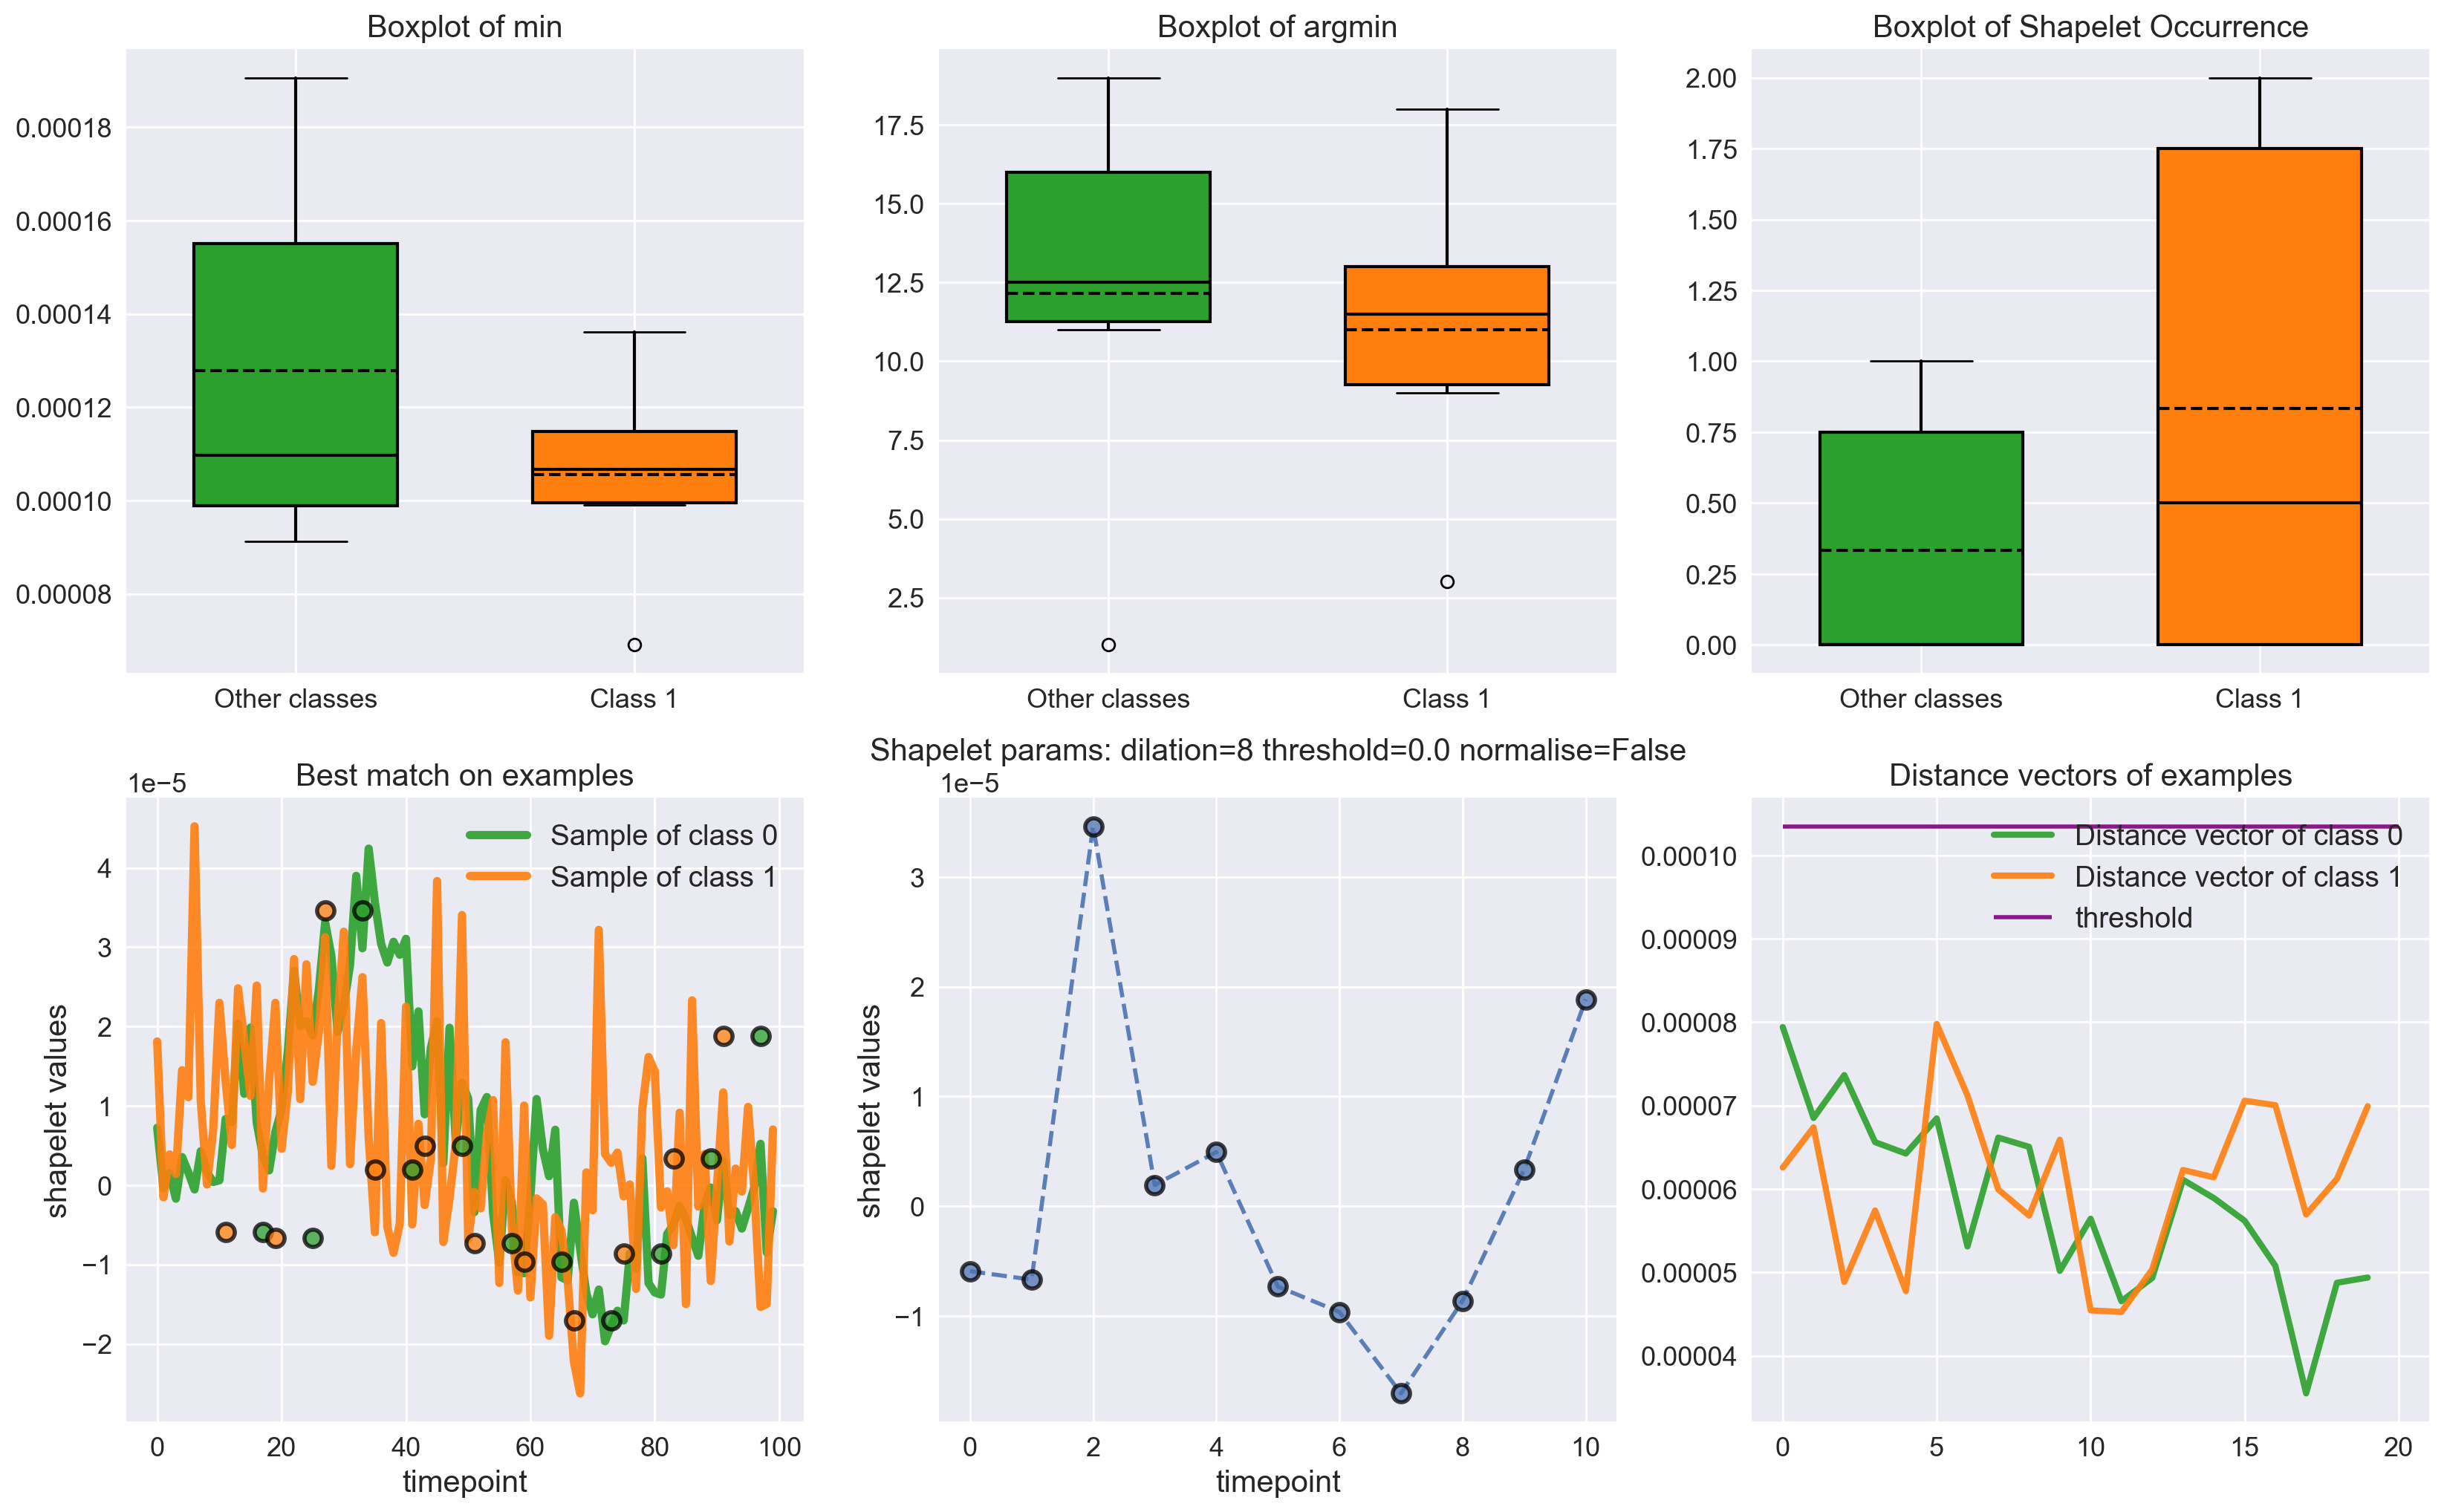

In [19]:
rdst_vis = ShapeletClassifierVisualizer(rdst)

fig = rdst_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    1,
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
)

In [20]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         6
        task       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Матрица ошибок:
[[6 0]
 [0 6]]


Candidates generated: 150
Selected top shapelets: 20
Top-5 scores: [0.8489 0.717  0.4889 0.4183 0.4111]



Manual shapelet-features classifier:
              precision    recall  f1-score   support

        rest       1.00      0.33      0.50         6
        task       0.60      1.00      0.75         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62        12
weighted avg       0.80      0.67      0.62        12



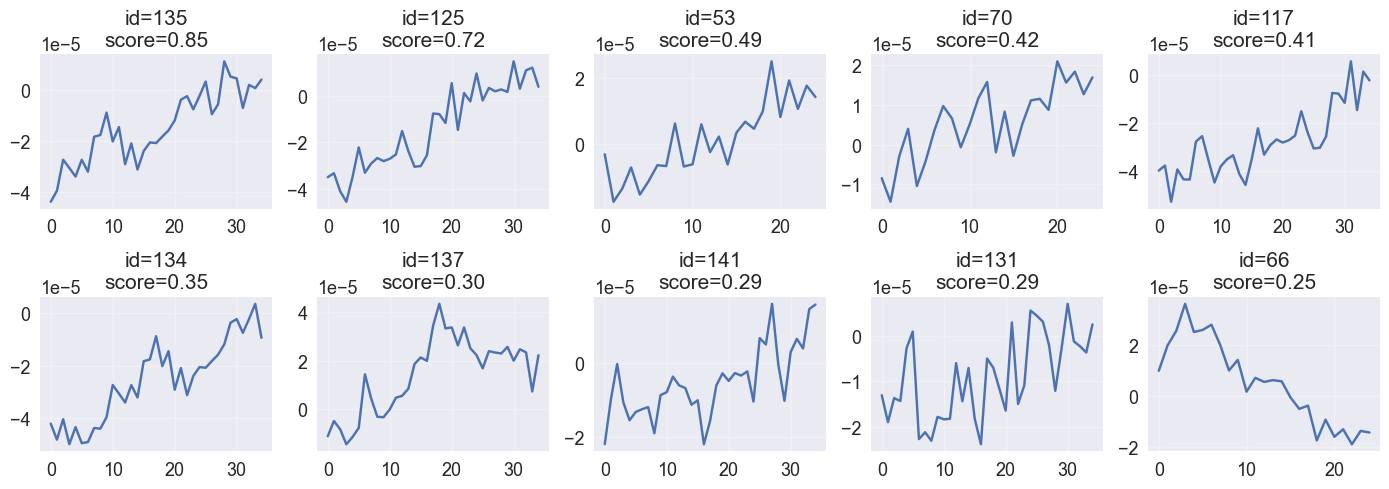

In [21]:
# Manual shapelet pipeline: candidates -> distances -> scores -> classifier
from sklearn.ensemble import RandomForestClassifier

Xtr = X_train[:, 0, :].astype(float)
Xte = X_test[:, 0, :].astype(float)
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

def z_norm(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + eps)

def shapelet_distance(series, shapelet):
    s = z_norm(series)
    shp = z_norm(shapelet)
    w = len(shp)
    best = np.inf
    for i in range(len(s) - w + 1):
        window = z_norm(s[i:i + w])
        d = np.sqrt(np.mean((window - shp) ** 2))
        if d < best:
            best = d
    return float(best)

def evaluate_shapelet(shapelet, X, y):
    d = np.array([shapelet_distance(x, shapelet) for x in X], dtype=float)
    classes = np.unique(y)
    means = np.array([d[y == c].mean() for c in classes], dtype=float)
    global_mean = d.mean()
    ss_between = np.sum([(y == c).sum() * (m - global_mean) ** 2 for c, m in zip(classes, means)])
    ss_within = float(np.sum([np.sum((d[y == c] - m) ** 2) for c, m in zip(classes, means)]))
    return float(ss_between / (ss_within + 1e-8))

def generate_candidates(X, lengths=(15, 25, 35), per_length=40, random_state=0):
    rng = np.random.default_rng(random_state)
    n, m = X.shape
    cands = []
    for L in lengths:
        if L >= m:
            continue
        for _ in range(per_length):
            i = int(rng.integers(0, n))
            j = int(rng.integers(0, m - L + 1))
            cands.append(X[i, j:j + L].copy())
    return cands

candidates = generate_candidates(Xtr, lengths=(15, 25, 35), per_length=50, random_state=0)
scores = np.array([evaluate_shapelet(shp, Xtr, ytr) for shp in candidates], dtype=float)

top_k = 20
top_ids = np.argsort(scores)[-top_k:][::-1]
top_shapelets = [candidates[i] for i in top_ids]

print(f'Candidates generated: {len(candidates)}')
print(f'Selected top shapelets: {len(top_shapelets)}')
print('Top-5 scores:', np.round(scores[top_ids[:5]], 4))

Xtr_feat = np.column_stack([[shapelet_distance(x, shp) for x in Xtr] for shp in top_shapelets])
Xte_feat = np.column_stack([[shapelet_distance(x, shp) for x in Xte] for shp in top_shapelets])

rf = RandomForestClassifier(n_estimators=300, random_state=0)
rf.fit(Xtr_feat, ytr)
pred_rf = rf.predict(Xte_feat)

print('\nManual shapelet-features classifier:')
print(classification_report(yte, pred_rf))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.ravel()
for ax, sid in zip(axes, top_ids[:10]):
    ax.plot(candidates[sid])
    ax.set_title(f'id={sid}\nscore={scores[sid]:.2f}')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
